In [1]:
"""12주차: 비지도학습과 K-Means 클러스터링 전체 파이프라인.

12주차 차시 1~3에서 다루는 비지도학습, K-Means, K 선택 실습
코드입니다.

데이터: sklearn 내장 breast_cancer (유방암 종양 측정값 — 클러스터링 대상)
환경: Google Colab
스타일: Google Python Style Guide

Contents:
    1. 라이브러리 임포트
    2. 데이터 로드 및 탐색 (차시 1)
    3. 스케일링 — 거리 기반이므로 필수 (차시 1)
    4. 첫 번째 K-Means 실행 — K=3 (차시 1~2)
    5. K-Means 알고리즘 확인 — 수렴 과정 (차시 2)
    6. 초기화의 영향 — n_init과 Inertia (차시 2)
    7. 엘보 방법 — K=2~10 Inertia 기록 (차시 3)
    8. 엘보 그래프 시각화 (차시 3)
    9. 실루엣 점수 — K=2~10 계산 (차시 3)
    10. 엘보 + 실루엣 그래프 나란히 비교 (차시 3)
    11. K 선택 — 두 지표 종합 판단 (차시 3)
    12. 최종 실행 — K=2 (차시 3)
    13. 클러스터 해석 — 피처 평균 비교 (차시 3)
    14. 클러스터 vs 실제 레이블 — 비지도학습의 가치 (차시 3)
    15. 그래프 시각화 — 클러스터별 피처 비교 (차시 3)
"""

'12주차: 비지도학습과 K-Means 클러스터링 전체 파이프라인.\n\n12주차 차시 1~3에서 다루는 비지도학습, K-Means, K 선택 실습\n코드입니다.\n\n데이터: sklearn 내장 breast_cancer (유방암 종양 측정값 — 클러스터링 대상)\n환경: Google Colab\n스타일: Google Python Style Guide\n\nContents:\n    1. 라이브러리 임포트\n    2. 데이터 로드 및 탐색 (차시 1)\n    3. 스케일링 — 거리 기반이므로 필수 (차시 1)\n    4. 첫 번째 K-Means 실행 — K=3 (차시 1~2)\n    5. K-Means 알고리즘 확인 — 수렴 과정 (차시 2)\n    6. 초기화의 영향 — n_init과 Inertia (차시 2)\n    7. 엘보 방법 — K=2~10 Inertia 기록 (차시 3)\n    8. 엘보 그래프 시각화 (차시 3)\n    9. 실루엣 점수 — K=2~10 계산 (차시 3)\n    10. 엘보 + 실루엣 그래프 나란히 비교 (차시 3)\n    11. K 선택 — 두 지표 종합 판단 (차시 3)\n    12. 최종 실행 — K=2 (차시 3)\n    13. 클러스터 해석 — 피처 평균 비교 (차시 3)\n    14. 클러스터 vs 실제 레이블 — 비지도학습의 가치 (차시 3)\n    15. 그래프 시각화 — 클러스터별 피처 비교 (차시 3)\n'

# 12주차: 비지도학습과 K-Means 클러스터링
### 📊 데이터: sklearn breast_cancer → 종양 측정값 30개 피처 — 비지도학습(y 없이 구조 발견)
---
## 차시 1
- **비지도학습**: y(정답) 없이 데이터의 구조·패턴을 발견 — 「정답 없음 ≠ 쓸모없음」
- **클러스터링**: 비슷한 데이터 포인트를 그룹으로 묶기 — 같은 클러스터: 비슷, 다른 클러스터: 다름
- **분류 vs. 클러스터링**: 분류=카테고리 미리 있음(예측) / 클러스터링=카테고리 없음(발견)
- **비슷하다 = 거리**: 유클리드 거리, 2주차 k-NN과 같은 원리, **스케일링 필수**
- **K는 사용자가 정한다**: 데이터가 알아서 정해 주지 않는다

## 차시 2
- **3단계 반복**: Step 0 초기화 → Step 1 할당(가장 가까운 중심점) → Step 2 갱신(평균으로 이동) → 수렴
- **K-Means** = K개의 평균(Mean)을 찾는 알고리즘 — 이름 자체가 핵심
- **초기화 문제**: 출발점에 따라 결과가 다를 수 있다 (지역 최적해)
- **해결책**: k-means++(서로 멀리 배치) + n_init=10(10번 실행 최선 선택) — scikit-learn 기본값
- **관성(Inertia)**: 클러스터 내 거리 제곱합, 작을수록 좋음. K↑ → 항상↓

## 차시 3
- **엘보 방법**: K vs Inertia 그래프에서 감소가 둔화되는 팔꿈치 = K 후보
- **실루엣 점수**: (b−a)/max(a,b), −1 ~ +1, 1에 가까울수록 좋은 클러스터링
- **K 선택 = 판단**: 엘보와 실루엣은 길잡이, 최종 결정은 활용 목적 + 도메인 지식
- **클러스터 해석**: 피처 평균 비교 → 패턴 발견 → 이름 부여 — 알고리즘이 제안, 사람이 완성

---
## Step 1. 라이브러리 임포트

In [2]:
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

print(f"scikit-learn: {__import__('sklearn').__version__}")
print(f"Python: {sys.version.split()[0]}")

scikit-learn: 1.6.1
Python: 3.12.12


---
## Step 2. 데이터 로드 및 탐색
- **데이터**: sklearn 내장 `breast_cancer` 데이터셋
- **피처 (30개)**: 종양의 반지름·둘레·넓이 등 세포핵 측정값 (mean / se / worst)
- **타겟**: 양성(1) / 악성(0) — 이진 분류 레이블이지만 **비지도학습에서는 사용하지 않음**
- **샘플 수**: 569개

**⚠ y는 있지만 fit(X)에서 X만 넣는다. y는 나중에 검증용으로만 참고**

In [3]:
data = load_breast_cancer()
X = data.data
y = data.target             # ⚠ 비지도학습에서는 사용하지 않음 — 검증용으로만!
feature_names = data.feature_names

print(f"피처 수  : {X.shape[1]}")
print(f"샘플 수  : {X.shape[0]}")
print(f"피처 이름(처음 5개): {list(feature_names[:5])}")
print(f"타겟 클래스: {list(data.target_names)}")
print(f"타겟 분포 : 양성(1)={np.sum(y==1)}명, 악성(0)={np.sum(y==0)}명")
print()
print("→ y(양성/악성)는 비지도학습에서 사용하지 않는다")
print("→ 나중에 결과 검증용으로만 참고한다")

피처 수  : 30
샘플 수  : 569
피처 이름(처음 5개): [np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness')]
타겟 클래스: [np.str_('malignant'), np.str_('benign')]
타겟 분포 : 양성(1)=357명, 악성(0)=212명

→ y(양성/악성)는 비지도학습에서 사용하지 않는다
→ 나중에 결과 검증용으로만 참고한다


In [4]:
# 피처 기초 통계 (상위 10개)
print("=== 피처 기초 통계 (상위 10개) ===")
df = pd.DataFrame(X, columns=feature_names)
df.iloc[:, :10].describe().round(4)

=== 피처 기초 통계 (상위 10개) ===


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension
count,569.0000,569.0000,569.000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000
mean,14.1273,19.2896,91.969,654.8891,0.0964,0.1043,0.0888,0.0489,0.1812,0.0628
std,3.5240,4.3010,24.299,351.9141,0.0141,0.0528,0.0797,0.0388,0.0274,0.0071
min,6.9810,9.7100,43.790,143.5000,0.0526,0.0194,0.0000,0.0000,0.1060,0.0500
25%,11.7000,16.1700,75.170,420.3000,0.0864,0.0649,0.0296,0.0203,0.1619,0.0577
50%,13.3700,18.8400,86.240,551.1000,0.0959,0.0926,0.0615,0.0335,0.1792,0.0615
75%,15.7800,21.8000,104.100,782.7000,0.1053,0.1304,0.1307,0.0740,0.1957,0.0661
max,28.1100,39.2800,188.500,2501.0000,0.1634,0.3454,0.4268,0.2012,0.3040,0.0974


---
## Step 3. 스케일링 — K-Means는 거리 기반이므로 필수

K-Means는 **거리(distance)** 로 「비슷함」을 판단합니다.
피처의 단위·범위가 다르면 단위가 큰 피처가 거리를 **지배**합니다.

`StandardScaler`: 각 피처의 평균을 0, 표준편차를 1로 변환

| 적용 전 | 적용 후 |
|---------|--------|
| 피처마다 범위 제각각 | 모든 피처 평균=0, 표준편차=1 |
| 거리 왜곡 | 거리 공정 |

**⚠ 지도학습에서는 X_train에만 fit했지만,
비지도학습은 train/test 분리가 없으므로 전체 X에 fit_transform 사용**

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("=== 스케일링 전후 비교 ===")
print(
    f"스케일링 전 — mean radius  범위: "
    f"{X[:, 0].min():.1f} ~ {X[:, 0].max():.1f}"
)
print(
    f"스케일링 전 — mean area    범위: "
    f"{X[:, 3].min():.1f} ~ {X[:, 3].max():.1f}"
)
print(
    f"스케일링 후 — 평균: {X_scaled.mean():.4f}, "
    f"표준편차: {X_scaled.std():.4f}"
)
print()
print("→ 스케일링 후 평균 ≈ 0, 표준편차 ≈ 1 확인")
print("→ 모든 피처가 동등한 기준 → 거리 계산이 공정해짐")

=== 스케일링 전후 비교 ===
스케일링 전 — mean radius  범위: 7.0 ~ 28.1
스케일링 전 — mean area    범위: 143.5 ~ 2501.0
스케일링 후 — 평균: -0.0000, 표준편차: 1.0000

→ 스케일링 후 평균 ≈ 0, 표준편차 ≈ 1 확인
→ 모든 피처가 동등한 기준 → 거리 계산이 공정해짐


---
## Step 4. 첫 번째 K-Means 실행 — K=3으로 시작
- `fit(X)` — **y가 없다!** → 비지도학습의 코드적 증거
- `labels_`: 각 데이터의 클러스터 번호 (0, 1, 2) — 이름이 아닌 번호
- `cluster_centers_`: K개 중심점 좌표
- `inertia_`: 관성 — 클러스터 내 거리 제곱합

**K=3은 임의 선택** — 최적이라는 근거 없음. Step 7에서 체계적으로 탐색한다

In [6]:
kmeans_3 = KMeans(n_clusters=3, random_state=42)
kmeans_3.fit(X_scaled)          # ← y가 없다! X만!

labels_3 = kmeans_3.labels_
centers_3 = kmeans_3.cluster_centers_

print("K-Means (K=3) 결과")
print("=" * 45)
print(f"클러스터별 데이터 수: "
      f"{[(labels_3 == i).sum() for i in range(3)]}")
print(f"중심점 shape      : {centers_3.shape}")
print(f"Inertia           : {kmeans_3.inertia_:.2f}")
print()
print("→ K=3은 출발점. 여러 K를 체계적으로 비교해야 한다")

K-Means (K=3) 결과
클러스터별 데이터 수: [np.int64(97), np.int64(118), np.int64(354)]
중심점 shape      : (3, 30)
Inertia           : 10066.28

→ K=3은 출발점. 여러 K를 체계적으로 비교해야 한다


---
## Step 5. K-Means 알고리즘 확인 — 3단계 반복과 수렴

| Step | 이름 | 동작 |
|------|------|------|
| Step 0 | 초기화 | K개 중심점을 배치 (k-means++ 기본값) |
| Step 1 | 할당 | 각 데이터를 가장 가까운 중심점에 배정 |
| Step 2 | 갱신 | 중심점을 클러스터 평균 위치로 이동 |

할당이 바뀌지 않을 때까지 반복 → **수렴(Convergence)**

| 비유 | 캠퍼스에 급수대 K개 설치 — 모든 학생이 가장 가까운 급수대까지의 총 거리를 최소화하도록 급수대 위치를 반복 조정 |

**K-Means** = K개의 **Means(평균)** 을 찾는 알고리즘 — 이름 자체가 핵심.
Step 2에서 중심점을 「평균 위치」로 이동하는 것이 이름의 근거

In [7]:
# 수렴까지 반복 횟수 확인
print(f"수렴까지 반복 횟수: {kmeans_3.n_iter_}회")
print()
print("→ 보통 5~30회 반복으로 수렴한다")
print("→ 컴퓨터 속도로는 순식간이다")

수렴까지 반복 횟수: 25회

→ 보통 5~30회 반복으로 수렴한다
→ 컴퓨터 속도로는 순식간이다


---
## Step 6. 초기화의 영향 — n_init과 Inertia

같은 데이터, 같은 K=3이어도 **초기 중심점 위치에 따라 결과가 다를 수 있다**
→ 지역 최적해(Local Optimum) 문제

| 비유 | 산에서 눈을 감고 위로만 걷는다 → 출발점에 따라 올라가는 봉우리가 다르다 |

### 해결책 (둘 다 scikit-learn 기본값!)
| 해결책 | 설명 | 기본값 |
|--------|------|--------|
| k-means++ | 초기 중심점들을 서로 멀리 배치 | `init='k-means++'` |
| n_init=10 | 10번 실행 후 Inertia 최소인 결과 선택 | `n_init=10` |

→ `KMeans(n_clusters=3, random_state=42)`만 써도 자동 적용

In [8]:
# n_init=1로 여러 번 실행 → Inertia가 다름을 확인
print("=== 초기화에 따른 Inertia 변화 (n_init=1) ===")
for trial in range(5):
    km = KMeans(n_clusters=3, n_init=1, random_state=trial)
    km.fit(X_scaled)
    print(f"  실행 {trial + 1}: Inertia = {km.inertia_:.2f}")

# 기본값(n_init=10)과 비교
km_default = KMeans(n_clusters=3, random_state=42)
km_default.fit(X_scaled)
print()
print(f"기본값 (n_init=10): Inertia = {km_default.inertia_:.2f}")
print()
print("→ n_init=10이 10번 중 최선(Inertia 최소)을 자동 선택한다")

=== 초기화에 따른 Inertia 변화 (n_init=1) ===
  실행 1: Inertia = 10066.28
  실행 2: Inertia = 10066.28
  실행 3: Inertia = 10061.80
  실행 4: Inertia = 10061.80
  실행 5: Inertia = 10061.80

기본값 (n_init=10): Inertia = 10066.28

→ n_init=10이 10번 중 최선(Inertia 최소)을 자동 선택한다


---
## Step 7. 엘보 방법 — K=2~10으로 Inertia 기록
- K를 늘리면 Inertia는 **항상 감소** → Inertia만으로는 최적 K를 못 찾음
- 「감소가 둔화되는 지점」 = 팔꿈치(elbow) = 적절한 K의 후보

### 기대 패턴
| 구간 | 감소폭 | 의미 |
|------|--------|------|
| K=2→3 | 가장 큰 감소 | 구조적으로 의미 있는 분리 |
| K=3→4 | 아직 의미 있는 감소 | 엘보 후보 구간 |
| K=5 이후 | 거의 평평 | K를 늘려도 큰 개선 없음 |

In [9]:
K_range = range(2, 11)
inertias = []

print(f"{'K':<5} {'Inertia':>12}")
print("-" * 20)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    print(f"{k:<5} {km.inertia_:>12.2f}")

print()
print("→ K가 커질수록 Inertia는 항상 감소한다")
print("→ 숫자만으로는 어디서 꺾이는지 판단 어렵다 → 그래프로!")

K          Inertia
--------------------
2         11595.68
3         10066.28
4          9266.15
5          9263.40
6          8562.88
7          8016.37
8          7288.48
9          7040.99
10         6668.85

→ K가 커질수록 Inertia는 항상 감소한다
→ 숫자만으로는 어디서 꺾이는지 판단 어렵다 → 그래프로!


---
## Step 8. 엘보 그래프 시각화
- x축: K (클러스터 수), y축: Inertia
- 급격히 감소하다가 완만해지는 지점 = **팔꿈치(elbow)**
- 팔꿈치 근처 K = 적절한 클러스터 수의 후보

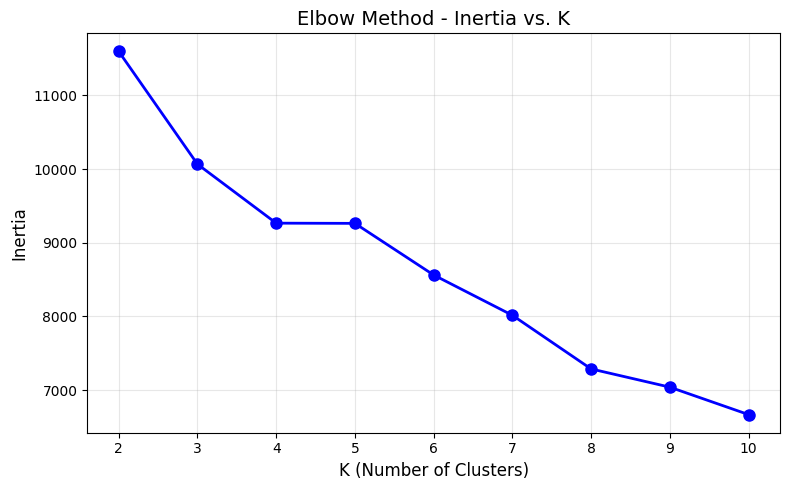

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(list(K_range), inertias, "bo-", linewidth=2, markersize=8)
plt.xlabel("K (Number of Clusters)", fontsize=12)
plt.ylabel("Inertia", fontsize=12)
plt.title("Elbow Method - Inertia vs. K", fontsize=14)
plt.xticks(list(K_range))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Step 9. 실루엣 점수(Silhouette Score) — K=2~10 계산

「각 데이터 포인트가 자기 클러스터에 얼마나 잘 속하는지」를 측정

`s(i) = (b(i) − a(i)) / max(a(i), b(i))`  범위: −1 ~ +1

| 값 | a(i) | b(i) | 해석 |
|----|------|------|------|
| a | 같은 클러스터 내 평균 거리 | — | 작을수록 좋음 (촘촘) |
| b | 가장 가까운 다른 클러스터까지 평균 거리 | — | 클수록 좋음 (분리) |
| s ≈ +1 | a 작고 b 큼 | — | 이상적 배정 |
| s ≈ 0 | a ≈ b | — | 경계에 위치 |
| s < 0 | a > b | — | 재검토 필요 |

**Inertia와 결정적 차이**: K↑이면 실루엣은 반드시 증가하지 않음 → 최적 K 탐색 가능

In [11]:
silhouette_scores = []

print(f"{'K':<5} {'Inertia':>12} {'Silhouette':>12}")
print("-" * 32)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    silhouette_scores.append(sil)
    print(f"{k:<5} {km.inertia_:>12.2f} {sil:>12.4f}")

print()
print("→ Inertia: K↑ → 항상↓ (차시 2에서 예고한 대로)")
print("→ Silhouette: K↑ → 반드시 증가하지 않음! K=2에서 가장 높음")

K          Inertia   Silhouette
--------------------------------
2         11595.68       0.3447
3         10066.28       0.3152
4          9266.15       0.2742
5          9263.40       0.1645
6          8562.88       0.1451
7          8016.37       0.1470
8          7288.48       0.1619
9          7040.99       0.1439
10         6668.85       0.1471

→ Inertia: K↑ → 항상↓ (차시 2에서 예고한 대로)
→ Silhouette: K↑ → 반드시 증가하지 않음! K=2에서 가장 높음


---
## Step 10. 엘보 + 실루엣 — 두 그래프 나란히 비교
- **왼쪽**: 엘보 — K=3~4 근처에서 감소 둔화 전환점 탐색
- **오른쪽**: 실루엣 — 어느 K에서 가장 높은지 확인

### 그래프 해석 포인트
| 그래프 | 확인할 것 | 의미 |
|--------|----------|------|
| 엘보 (왼쪽) | 팔꿈치 위치 | 감소가 둔화되는 K |
| 실루엣 (오른쪽) | 최고점 K | 가장 잘 나뉜 K |

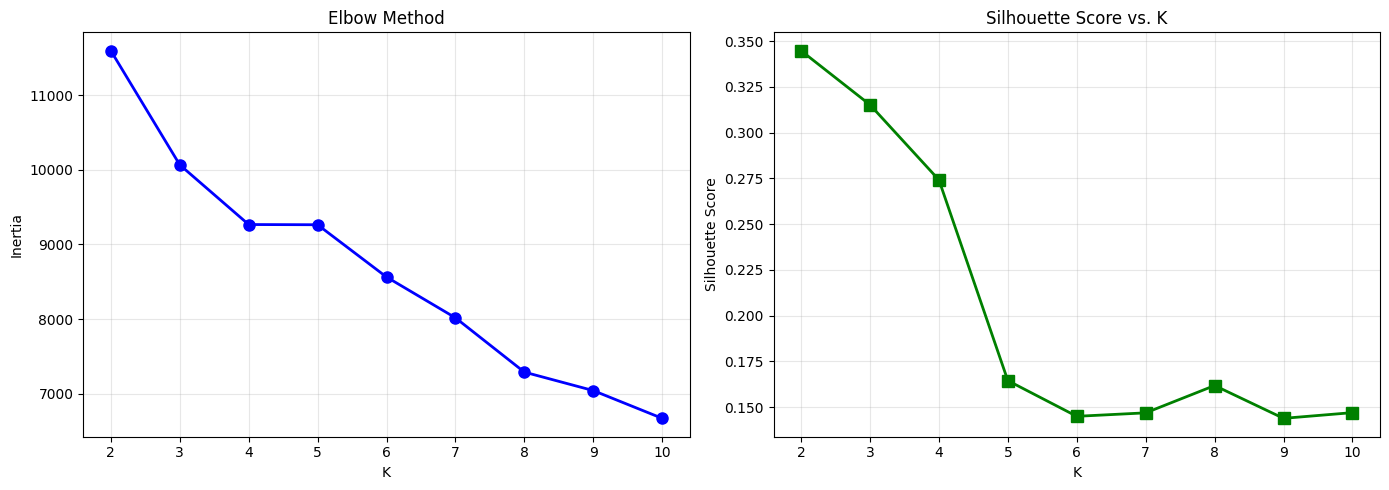

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: 엘보
axes[0].plot(list(K_range), inertias, "bo-", linewidth=2, markersize=8)
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method")
axes[0].set_xticks(list(K_range))
axes[0].grid(True, alpha=0.3)

# 오른쪽: 실루엣
axes[1].plot(list(K_range), silhouette_scores, "gs-", linewidth=2, markersize=8)
axes[1].set_xlabel("K")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score vs. K")
axes[1].set_xticks(list(K_range))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Step 11. K 선택 — 두 지표를 종합하여 판단

| K | 엘보 (Inertia 감소폭) | 실루엣 점수 | 비고 |
|---|----------------------|------------|------|
| K=2 | 가장 큰 감소폭 | ★ 최고 | 실제 구조(양성/악성)와 일치 |
| K=3 | 꽤 큰 감소 (엘보 후보) | 양호 | 세 그룹으로 세밀 분석 가능 |
| K=4 | 의미 있는 감소 | 보통 | |
| K=5+ | 거의 평평 | 계속 낮아짐 | 과도한 분할 |

**두 지표가 다른 답을 제안하는 것은 정상** — 이것이 K 선택이 「판단」인 이유

→ **K=2 선택**: 실루엣 최고 + breast_cancer 실제 구조(2개 클래스)와 일치 + 해석 명확

**⚠ 엘보와 실루엣은 「참고 도구」이지 「결정자」가 아니다.
최종 결정은 활용 목적과 도메인 지식에 기반한다.**

In [13]:
# 두 지표를 표로 종합
df_summary = pd.DataFrame({
    "K": list(K_range),
    "Inertia": [round(v, 2) for v in inertias],
    "Silhouette": [round(v, 4) for v in silhouette_scores],
})

print("=" * 40)
print("K 선택 — 두 지표 종합")
print("=" * 40)
print(df_summary.to_string(index=False))
print()
print(f"→ 실루엣 최고 K = {df_summary.loc[df_summary['Silhouette'].idxmax(), 'K']}")
print("→ K=2 선택: 실루엣 최고 + 실제 데이터 구조와 일치")

K 선택 — 두 지표 종합
 K  Inertia  Silhouette
 2 11595.68      0.3447
 3 10066.28      0.3152
 4  9266.15      0.2742
 5  9263.40      0.1645
 6  8562.88      0.1451
 7  8016.37      0.1470
 8  7288.48      0.1619
 9  7040.99      0.1439
10  6668.85      0.1471

→ 실루엣 최고 K = 2
→ K=2 선택: 실루엣 최고 + 실제 데이터 구조와 일치


---
## Step 12. 최종 실행 — K=2로 클러스터링
- K=2 선택 근거: 실루엣 최고 + 실제 데이터 구조(양성/악성)와 일치
- 클러스터 번호(0, 1)는 단순 번호 — 의미는 피처를 분석해서 부여

**클러스터 번호가 붙었다고 끝이 아니다
— 각 그룹의 특성을 해석하는 것이 진짜 작업**

In [14]:
kmeans_final = KMeans(n_clusters=2, random_state=42)
labels_final = kmeans_final.fit_predict(X_scaled)

print("K=2 최종 클러스터링 결과")
print("=" * 45)
print(f"클러스터 0: {(labels_final == 0).sum()}개")
print(f"클러스터 1: {(labels_final == 1).sum()}개")
print(f"Inertia   : {kmeans_final.inertia_:.2f}")
print(f"Silhouette: {silhouette_score(X_scaled, labels_final):.4f}")

K=2 최종 클러스터링 결과
클러스터 0: 188개
클러스터 1: 381개
Inertia   : 11595.68
Silhouette: 0.3447


---
## Step 13. 클러스터 해석 — 피처 평균 비교

알고리즘은 클러스터 0과 1로만 구분했다.
「측정값 큰 그룹」이라는 이름은 **분석가가 피처를 보고 부여하는 것**

### 이름 붙이기 과정
| Step | 작업 |
|------|------|
| 1 | 피처 평균 비교 — 어떤 피처에서 차이가 크게 나는지 확인 |
| 2 | 패턴 발견 — 일관된 방향성이 있는지 확인 |
| 3 | 이름 부여 — 분석가(교사)의 전문성으로 의미 있는 이름 결정 |
| 4 | 결과 활용 — 각 그룹 특성 이해 → 맞춤 전략 수립 |

| 비유 | 학생 그룹 0·1·2에 「적극 참여형」·「조용한 성실형」을 붙이는 것과 같은 과정 |

**⚠ 원본 X(스케일링 전)로 비교해야 해석하기 쉽다** — 17.5mm는 직관적, -1.2는 아님

In [15]:
# 대표 피처 5개 비교 (원본 스케일)
important_idx = [0, 2, 3, 20, 22]  # radius, perimeter, area (mean/worst)

print("=== 클러스터별 피처 평균 (대표 5개, 원본 스케일) ===")
print(f"{'피처':<25} {'클러스터 0':>12} {'클러스터 1':>12}")
print("-" * 52)
for idx in important_idx:
    m0 = X[labels_final == 0, idx].mean()
    m1 = X[labels_final == 1, idx].mean()
    print(f"{feature_names[idx]:<25} {m0:>12.2f} {m1:>12.2f}")

=== 클러스터별 피처 평균 (대표 5개, 원본 스케일) ===
피처                              클러스터 0       클러스터 1
----------------------------------------------------
mean radius                      17.60        12.41
mean perimeter                  116.70        79.77
mean area                       997.63       485.77
worst radius                     21.35        13.76
worst perimeter                 143.44        89.41


In [16]:
# 전체 30개 피처 비교 + 차이가 큰 상위 5개 자동 추출
diffs = []
for idx in range(X.shape[1]):
    m0 = X[labels_final == 0, idx].mean()
    m1 = X[labels_final == 1, idx].mean()
    diffs.append((feature_names[idx], m0, m1, abs(m0 - m1)))

diffs.sort(key=lambda x: x[3], reverse=True)

print("=== 두 클러스터 간 차이가 가장 큰 피처 Top 5 ===")
print(f"{'피처':<25} {'클러스터 0':>12} {'클러스터 1':>12} {'차이':>10}")
print("-" * 62)
for name, m0, m1, d in diffs[:5]:
    print(f"{name:<25} {m0:>12.2f} {m1:>12.2f} {d:>10.2f}")

print()
print("→ 이 5개 피처가 두 그룹을 가장 잘 구분하는 특성이다")
print("→ 클러스터 0: 측정값이 큰 그룹 / 클러스터 1: 측정값이 작은 그룹")

=== 두 클러스터 간 차이가 가장 큰 피처 Top 5 ===
피처                              클러스터 0       클러스터 1         차이
--------------------------------------------------------------
worst area                     1457.36       595.98     861.38
mean area                       997.63       485.77     511.87
area error                       77.32        22.09      55.24
worst perimeter                 143.44        89.41      54.03
mean perimeter                  116.70        79.77      36.93

→ 이 5개 피처가 두 그룹을 가장 잘 구분하는 특성이다
→ 클러스터 0: 측정값이 큰 그룹 / 클러스터 1: 측정값이 작은 그룹


---
## Step 14. 클러스터 레이블 vs 실제 레이블 — 비지도학습의 가치

y를 **전혀 사용하지 않고** X만으로 클러스터링했다.
결과가 실제 양성/악성 구조와 일치하는지 확인한다.

→ 이것이 **「정답 없이 구조를 발견한다」** 의 구체적 의미

**⚠ 이 비교는 breast_cancer처럼 실제 레이블이 있을 때만 가능하다.
진짜 비지도학습 상황에서는 y 자체가 없으므로 이런 검증이 불가능하다.**

In [17]:
# 교차표: 클러스터 vs 실제 레이블
ct = pd.crosstab(
    labels_final, y,
    rownames=["Cluster"], colnames=["Actual (0=malignant, 1=benign)"],
)
print("=== 클러스터 vs 실제 레이블 교차표 ===")
print(ct)
print()

# 일치율 계산 (클러스터 번호가 뒤바뀔 수 있으므로 두 경우 모두 확인)
match_a = np.sum((labels_final == 0) & (y == 0)) + np.sum(
    (labels_final == 1) & (y == 1)
)
match_b = np.sum((labels_final == 0) & (y == 1)) + np.sum(
    (labels_final == 1) & (y == 0)
)
best_match = max(match_a, match_b)
print(f"일치율: {best_match}/{len(y)} = {best_match / len(y):.4f}")
print()
print("→ y 없이 X만으로 실제 구조를 발견 — 비지도학습의 핵심 가치!")

=== 클러스터 vs 실제 레이블 교차표 ===
Actual (0=malignant, 1=benign)    0    1
Cluster                                 
0                               175   13
1                                37  344

일치율: 519/569 = 0.9121

→ y 없이 X만으로 실제 구조를 발견 — 비지도학습의 핵심 가치!


---
## Step 15. 그래프 시각화 — 클러스터별 피처 비교
- 차이가 큰 상위 5개 피처의 클러스터별 평균을 **막대그래프**로 시각화
- 두 그룹이 어떤 피처에서 가장 크게 다른지 시각적으로 확인

### 그래프 해석 포인트
| 확인할 것 | 의미 |
|----------|------|
| 두 막대의 차이가 큰 피처 | 그룹을 구분하는 핵심 특성 |
| 일관된 방향성 | 한 그룹이 모든 측정값에서 높다면 체계적 차이 |

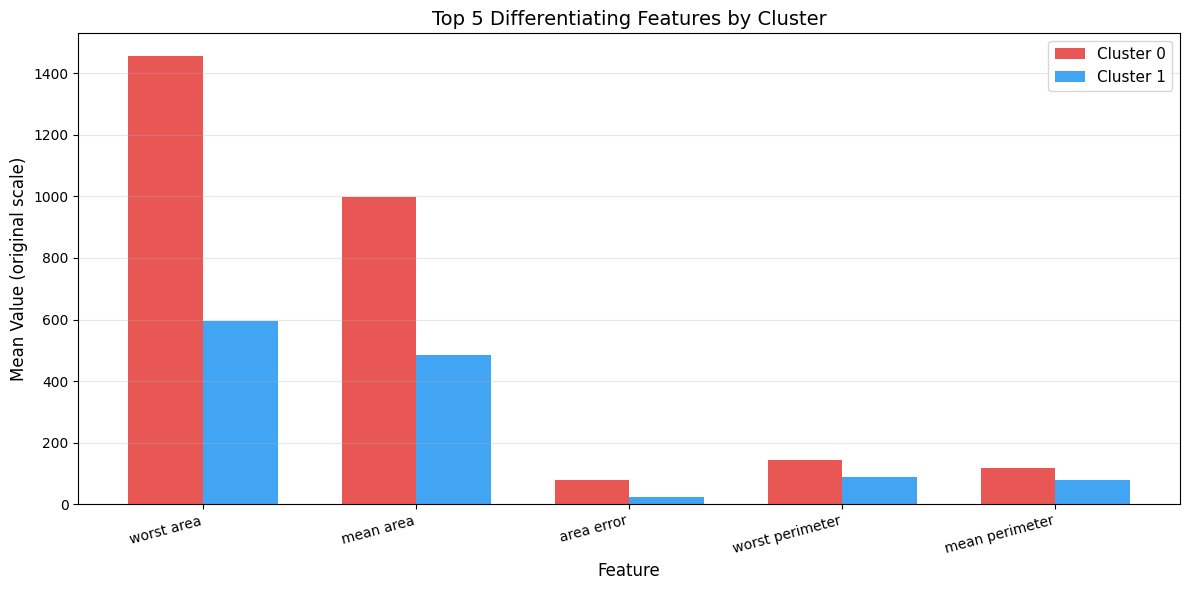

In [18]:
# 차이 큰 상위 5개 피처 시각화
top5 = diffs[:5]
feat_labels = [d[0] for d in top5]
m0_vals = [d[1] for d in top5]
m1_vals = [d[2] for d in top5]

x_pos = np.arange(len(feat_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x_pos - width / 2, m0_vals, width, label="Cluster 0",
               color="#E53935", alpha=0.85)
bars2 = ax.bar(x_pos + width / 2, m1_vals, width, label="Cluster 1",
               color="#2196F3", alpha=0.85)

ax.set_xlabel("Feature", fontsize=12)
ax.set_ylabel("Mean Value (original scale)", fontsize=12)
ax.set_title("Top 5 Differentiating Features by Cluster", fontsize=14)
ax.set_xticks(x_pos)
ax.set_xticklabels(feat_labels, rotation=15, ha="right")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

In [19]:
print("=" * 60)
print("11주차 K-Means 클러스터링 실습 완료")
print("=" * 60)
print()
print("⚠ 주의: 클러스터링 결과는 데이터, K, 스케일링에 따라 달라집니다.")
print("  K 선택은 정답이 아니라 판단입니다.")
print("  엘보와 실루엣은 참고 도구이며, 최종 결정은 활용 목적에 따릅니다.")
print("  항상 여러 K를 시도하고 피처를 분석하여 해석하는 것이 정답입니다.")
print()
print("12주차 예고: PCA(주성분 분석)")
print("  30개 피처를 2~3개 축으로 요약하여 클러스터링 결과를 2차원에 시각화")
print("  오늘의 K=2 결과를 눈으로 직접 확인하게 됩니다.")

11주차 K-Means 클러스터링 실습 완료

⚠ 주의: 클러스터링 결과는 데이터, K, 스케일링에 따라 달라집니다.
  K 선택은 정답이 아니라 판단입니다.
  엘보와 실루엣은 참고 도구이며, 최종 결정은 활용 목적에 따릅니다.
  항상 여러 K를 시도하고 피처를 분석하여 해석하는 것이 정답입니다.

12주차 예고: PCA(주성분 분석)
  30개 피처를 2~3개 축으로 요약하여 클러스터링 결과를 2차원에 시각화
  오늘의 K=2 결과를 눈으로 직접 확인하게 됩니다.
